## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import gdown
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import *
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from pathlib import Path
import pandas as pd
import tqdm

Using cpu device

In [2]:
# Download file from google drive

file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"

# download the file
input_file = Path("../models/demo_chain.root")

if not input_file.exists():
    # download the file
    input_file.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(file_url, str(input_file), quiet=False, fuzzy=True)


In [65]:
# Set up file properties
#chain_name = 'posteriors'
#verbose=False

#chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)

Okay, now we've loaded in a file we need to do a bit of processing. This means we need to select the variables we care about and apply parameter cuts

In [66]:
# Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
#chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])

# Now we add parameters we care about. Note this only need to be a substring of the full name
#chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])

# The fitting label is special, it's the thing we want to train our network to predict
#fitting_label = "LogL"
# We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
#chain_handler.add_additional_plots(fitting_label, True)

In [14]:
#new version to try and work with combo masses
def get_mean_for_col(data_frame: pd.DataFrame, col_we_care_about: str, greater_than: bool, split_col="delm2_23"):
    if greater_than:
        return np.mean(data_frame[data_frame[split_col]>0][col_we_care_about])
    else:
        return np.mean(data_frame[data_frame[split_col]<0][col_we_care_about])

def do_grid_search(ml_model):
    #OPTIONAL Do the grid search over the training data using the params below
    param_grid = {
        "learning_rate":(0.001,0.01,0.1,1),
        "max_leaf_nodes":(50,100,200)
    }
    grid_search = RandomizedSearchCV(estimator=HistGradientBoostingRegressor(), param_distributions=param_grid, n_iter=10)
    training_data = ml_model.training_data #all x_sec columns etc
    target_data = ml_model._training_labels #log-likelihood 

    grid_search.fit(training_data, target_data)
    fit_params = grid_search.best_params_
    print("Best params found by grid search:")
    print(fit_params)

    max_leaves = fit_params['max_leaf_nodes']
    lr = fit_params['learning_rate']

    return max_leaves, lr

def combo_ml_test_function(): 
    chain_handler = 0
    # Set up file properties
    chain_name = 'posteriors'
    verbose=False

    chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
    # Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
    chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov", "xsec_20", "xsec_19"])
    fitting_label = "LogL" #what target we want
    # Now we add parameters we care about. Note this only need to be a substring of the full name
    chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
    # We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
    chain_handler.add_additional_plots(fitting_label, True)

    #specify the cut for the mass being tested #REMOVE MASS CUT TO COMBO AGAIN##########################
    chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<1234", "step>10000", "delm2_23>0"])
    chain_handler.convert_ttree_to_array()

    #setup BCs SEE IF WE WANT TO GO PM 10% AGAIN OR NOT
    no_table = chain_handler.ttree_array[chain_handler.ttree_array["delm2_23"]>0]
    max_no = no_table.max().to_numpy(dtype=np.float64)[:-1].copy()
    min_no = no_table.min().to_numpy(dtype=np.float64)[:-1].copy()

    io_table = chain_handler.ttree_array[chain_handler.ttree_array["delm2_23"]<0]
    max_io = io_table.max().to_numpy(dtype=np.float64)[:-1].copy()
    min_io = io_table.min().to_numpy(dtype=np.float64)[:-1].copy()

    model_output=Path("../models/my_model")
    # Make sure the model output directory exists
    model_output.parent.mkdir(parents=True, exist_ok=True)
    # The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
    ml_factory = MLFactory(chain_handler, fitting_label, f"{model_output}.pdf")
    
    #Initialise the model here
    ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', max_iter=10000, verbose=1, max_leaf_nodes=40) 
    # Let's use 20% of the data for testing 
    ml_model.set_training_test_set(0.2)
        
    training_data = ml_model.training_data #all x_sec columns etc
    #target_data = ml_model._training_labels #log-likelihood    
    
    #OPTIONAL perform grid search to get the optimal parameters  
    #max_leaves, lr = do_grid_search(ml_model)

    max_leaves = 200
    lr = 0.01
    ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', 
                                        max_iter=10000, verbose=1, max_leaf_nodes=max_leaves, learning_rate=lr) 
    
    #train the ML model
    ml_model.set_training_test_set(0.2)
    ml_model.train_model()
    
    #make train and test plots for the ML model for completeness
    ml_model.test_model()
    
    return ml_model,training_data,min_no,max_no,min_io,max_io

#function to do MCMC for the parameters
def v2_run_mcmc(ml_model,training_data,min_no,max_no,min_io,max_io):

    NSTEPS: int = 1000
    NCHAINS = 1
    IN_BOUND_COUNT = np.zeros(NCHAINS)
    OUT_BOUND_COUNT = np.zeros(NCHAINS)
    ACCEPT_COUNT = np.zeros(NCHAINS)
    REJECT_COUNT = np.zeros(NCHAINS)

    min_no = min_no.copy()-(0.1*min_no*np.sign(min_no))
    max_no = max_no.copy()+(0.1*max_no*np.sign(max_no))
    min_io = min_io.copy()-(0.1*min_io*np.sign(min_io))
    max_io = max_io.copy()+(0.1*max_io*np.sign(max_io))

    #print(min_io[0],min_io[25])
    #print(max_io[0],max_io[25])

    start_step = training_data.iloc[0].to_numpy() #but this has 29 items
    start_step_many = np.tile(start_step, (NCHAINS,1))

    stored_steps = np.empty((NSTEPS+1, NCHAINS, len(start_step)))

    #stored_steps[0] = start_step #so this initialises with 27 items
    stored_steps[0] = start_step_many
    #so when we accept new points we need to have all parameters considered and their new values included

    #print(start_step_many)

    current_L = ml_model.model_predict_unscale(start_step_many)
    #print(current_L)
    stored_L = np.empty((NSTEPS+1,NCHAINS,len(start_step)))
    stored_L[0] = current_L

    col_labels = list(training_data.columns)

    mu_1 = []
    mu_2 = []

    #find the means of the IO and NO peaks, mu_1 and mu_2 respectively, for each row
    for p in range(0,len(col_labels)):
        mu_1.append(get_mean_for_col(training_data,col_labels[p],True)) #IO
        mu_2.append(get_mean_for_col(training_data,col_labels[p],True)) #NO

    mu_1 = np.array(mu_1)
    #print(mu_1)
    mu_2 = np.array(mu_2)
    #print(mu_2)
    step_sizes = np.ones(len(start_step))*(2.38**2)/(len(start_step))*(np.array(mu_1)**2)*0.8
    #print(step_sizes)
    #print(NSTEPS)
    #print(NCHAINS)
    #flipturn = 0  #turn these back on to flip

    #flip_random_nums = np.random.uniform(0,1, NSTEPS)
    accept_u = np.random.uniform(0,1,NSTEPS)

    #step_proposals = np.random.normal(0, step_sizes, (NSTEPS, len(step_sizes), NCHAINS))
    step_proposals = np.random.normal(0, step_sizes.reshape(1, 1, len(step_sizes)), (NSTEPS, NCHAINS, len(step_sizes)))
    #print(step_proposals[0])

    for s in tqdm.tqdm_notebook(range(NSTEPS)):
        x_t = stored_steps[s]    
        new_priors = x_t + step_proposals[s] #proposed priors

        #use mu to flip the mass ordering on a 50% chance basis
        #this should stop the MCMC getting stuck in local IO min.
        #R = flip_random_nums[s] #turn back on to flip again
        #print(R)

        #if R<0.5: #FLIP MASS ORDERING
         #  new_priors = (mu_1 - new_priors) + mu_2
           #print('flipped priors: '+str(new_priors))
          # flipturn += 1

        #proposed_L = ml_model.model_predict(new_priors) #returns logL based on new set of priors
        proposed_L = ml_model.model_predict_unscale(new_priors) #returns logL based on new set of priors
        current_L = current_L.flatten()
        proposed_L = proposed_L.flatten()
        #print(current_L)
        #print(proposed_L)

        #begin looping over multiple chains
        for ith_chain in range(0,NCHAINS): #turn this section back on for BC check

            #in_io = np.all(min_io<new_priors[ith_chain]) and np.all(new_priors[ith_chain]<max_io)
            #in_no = np.all(min_no<new_priors[ith_chain]) and np.all(new_priors[ith_chain]<max_no)

            #if in_io or in_no:
            #if in_no:
             #   delta_L = current_L[ith_chain]-proposed_L[ith_chain]
              #  accept_prob = min(np.exp(delta_L), 1)

                #accept_prob = min(np.exp(current_L[ith_chain]-proposed_L[ith_chain]), 1)
               # IN_BOUND_COUNT[ith_chain] += 1
                #print('in bounds')
            #else:
             #   accept_prob = 0
              #  OUT_BOUND_COUNT[ith_chain] += 1
                #print('out of bounds')
        

            delta_L = current_L[ith_chain]-proposed_L[ith_chain] #DELETE these lines when we turn
            accept_prob = min(np.exp(delta_L), 1) #the BC check back ON
            #print(f'accept p: {accept_prob}')
            u = accept_u[s]
            if u <= accept_prob: #accept proposal
                stored_steps[(s+1,ith_chain)] = new_priors[ith_chain]
                current_L[ith_chain] = proposed_L[ith_chain]
                #print('ACCEPTED')
                ACCEPT_COUNT[ith_chain] += 1
                
            if u > accept_prob: #reject proposal
                stored_steps[(s+1,ith_chain)] = stored_steps[(s,ith_chain)]
                #print('REJECTED')
                #print(f'param: {param}, io low: {iom}, io up: {iou}, no low: {nom}, no up: {nou}')
                REJECT_COUNT[ith_chain] += 1

            stored_L[(s+1,ith_chain)] = current_L[ith_chain] #update log-likelihood

    for i in range(0,NCHAINS):    
        print('\n')
        print(f'### {i} Chain ###')
        print('in bound count: '+str(IN_BOUND_COUNT[i]))
        print('out bound count: '+str(OUT_BOUND_COUNT[i]))
        print('accept count: '+str(ACCEPT_COUNT[i]))
        print('reject count: '+str(REJECT_COUNT[i]))
        #print('flipped count: '+str(flipturn))

    return stored_steps, stored_L

def get_table_hacky():
    chain_name = 'posteriors'
    verbose=False
    chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
    # Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
    chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov", "xsec_20", "xsec_19"])
    fitting_label = "LogL" #what target we want
    # Now we add parameters we care about. Note this only need to be a substring of the full name
    chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
    # We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
    chain_handler.add_additional_plots(fitting_label, True)

    #specify the cut for the mass being tested
    chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<1234", "step>10000"])
    chain_handler.convert_ttree_to_array()
    full_table = chain_handler.ttree_array

    return full_table.copy()

def do_bayes_factor(required_chain, label):
    #Find Bayes' factor for original MCMC fit
    NO_output = [p for p in required_chain if p>0]
    IO_output = [q for q in required_chain if q<0]
    bayes_factor = len(NO_output)/len(IO_output)
    print(f'{label} Bayes\' factor: {bayes_factor:.3f}')

In [68]:
#new version to try and work with combo masses
#from here we're going to do it for both mass orders together, so don't need the extra cut

#M23_combo, M23_combo_log_likelihood = combo_ml_test_function(combined_chain,fitting_label) #run function for normal ordering
#combo_ml_test_function() #run function for normal ordering

In [69]:
# def new_bcs(m,training_data,ml_model):
#     min_bc = []
#     max_bc = []

#     for j in range(m):
#         column = training_data.iloc[:,j].to_numpy() 
#         min_col_val = np.min(column)
#         max_col_val = np.max(column)
#         #adapt to include -+ 10% interval to the BCs in next test
#         min_bc.append(min_col_val-(0.1*min_col_val))
#         max_bc.append(max_col_val+(0.1*max_col_val))

#     #need to reshape as 2d array to be scaled
#     min_bc = np.array(min_bc).reshape(1, -1)
#     max_bc = np.array(max_bc).reshape(1, -1)
#     #apply scaling and flatten back into 1d
#     min_bc = ml_model.scale_data(min_bc).flatten()
#     max_bc = ml_model.scale_data(max_bc).flatten()
    
#     return min_bc, max_bc

# def setup_BCs(mass_cut):
#     chain_handler = 0
#     # Set up file properties
#     chain_name = 'posteriors'
#     verbose=False

#     chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
#     # Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
#     chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])
#     # Now we add parameters we care about. Note this only need to be a substring of the full name
#     chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
#     # The fitting label is special, it's the thing we want to train our network to predict
#     fitting_label = "LogL"
#     # We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
#     chain_handler.add_additional_plots(fitting_label, True)

#     #specify the cut for the mass being tested
#     chain_handler.add_new_cuts([mass_cut, "LogL_systematic_xsec_cov<1234", "step>10000"])
#     chain_handler.convert_ttree_to_array()
    
#     model_output=Path("../models/my_model")
#     # Make sure the model output directory exists
#     model_output.parent.mkdir(parents=True, exist_ok=True)
#     # The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
#     ml_factory = MLFactory(chain_handler, fitting_label, f"{model_output}.pdf")
    
#     #Initialise the model here
#     ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', max_iter=10000, verbose=1, max_leaf_nodes=40) 
#     # Let's use 20% of the data for testing 
#     ml_model.set_training_test_set(0.2)
#     training_data = ml_model.training_data #all x_sec columns etc
#     target_data = ml_model._training_labels #log-likelihood 

#     start_step = training_data.iloc[0].to_numpy() #but this has 29 items 
#     m = len(start_step)
#     new_min_bcs, new_max_bcs = new_bcs(m,training_data,ml_model)

#     return new_min_bcs, new_max_bcs

# #after we've established the training data and BCs for each cut we need to remake the ml model 
# #so use the combo ml function so that the training data used here will be for the FULL DATASET 
# #WITH NO CUTS for masses

Attempting to open ..\models\demo_chain.root
Succesfully opened ..\models\demo_chain.root:posteriors
Training Model
Binning 0.005 GB of training data: 0.071 s
Binning 0.001 GB of validation data: 0.001 s
Fitting gradient boosted rounds:
Fit 3275 trees in 132.041 s, (655000 total leaves)
Time spent computing histograms: 27.785s
Time spent finding best splits:  25.345s
Time spent applying splits:      15.636s
Time spent predicting:           0.626s


Training Results!

Mean Absolute Error : 0.020683132189034812

Line of best fit : y=1.0175990664579713x + 0.007185624326356018

Saving QQ to train_qq_plot.pdf

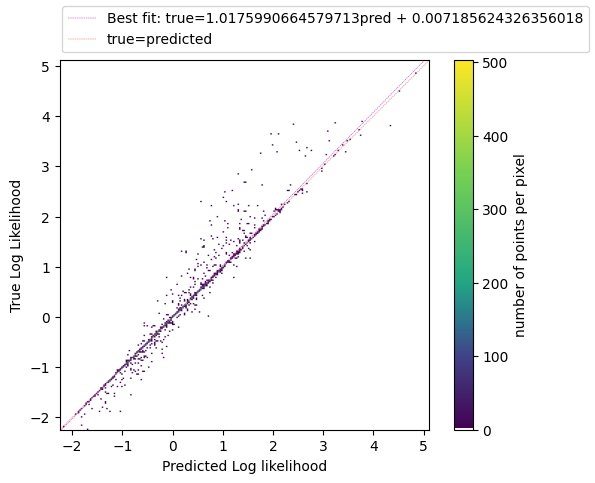

mean: 0.007061351138388276, std dev: 0.11473227847541127

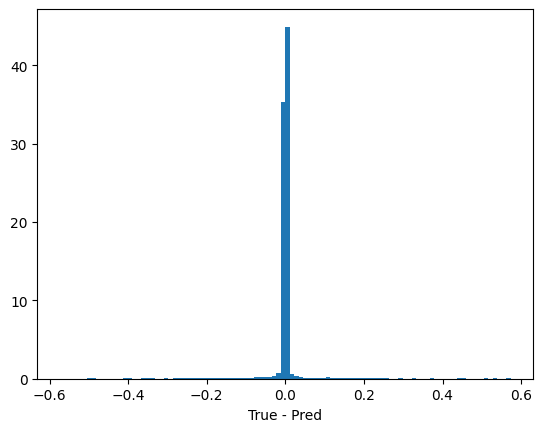

=====

Testing Results!

Mean Absolute Error : 0.029000712600458722

Line of best fit : y=1.0242996307864416x + 0.010669725660984406

Saving QQ to .pdf

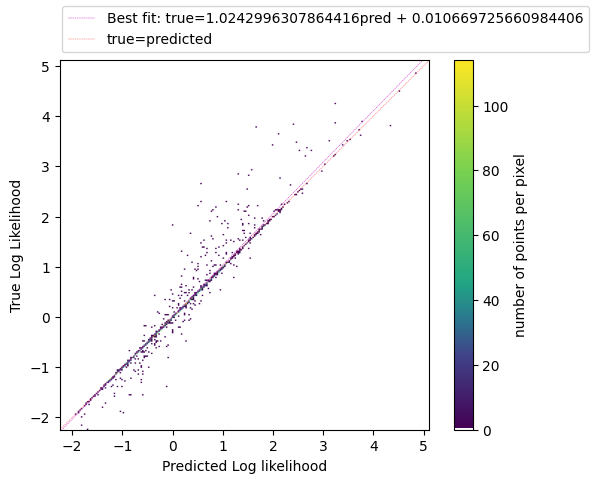

mean: 0.010473716431013157, std dev: 0.14050212139668797

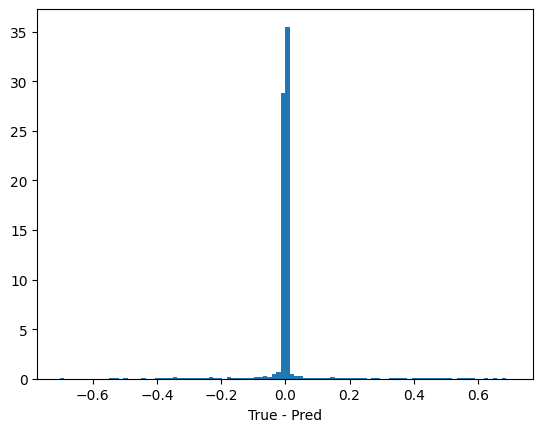

=====

In [4]:
#RUN COMBO FUNCTION NEXT, NEED TO ADAPT V2 MCMC TO USE THE NEW BCS FIRST THO
ml_model,training_data,min_no,max_no,min_io,max_io = combo_ml_test_function()
#KEEP THESE BLOCKS SEPARATE SO WE ONLY NEED TO TRAIN IT ONCE AND THEN USE THE GOOD OUTPUT

In [25]:
print(min_no)
print(max_no)

[ 6.78295377e-01  6.82533174e-01  7.03146952e-01  7.16973441e-01
  7.13837211e-01  7.48621735e-01  6.20067417e-01  6.66096013e-01
  6.88281247e-01  6.37243098e-01  6.02027614e-01  7.08588764e-01
  6.75949581e-01  6.86551760e-01  5.37060467e-01  3.37198007e-02
  9.42909922e-01  9.00768741e-01  4.65799372e-01 -2.94381075e-03
 -4.42493420e-03  2.62713329e-01  3.59358488e-01  8.35776759e-04
  6.88634495e-05  2.48793226e-03 -5.98491488e+00]
[1.35355599e+00 1.43272514e+00 1.44451907e+00 1.36382077e+00
 1.38422938e+00 1.38032926e+00 1.34496975e+00 1.33461496e+00
 1.40221874e+00 1.39822184e+00 1.45528580e+00 1.32431744e+00
 1.43505531e+00 1.39397681e+00 1.54885883e+00 2.09948981e+00
 1.12629182e+00 1.10724713e+00 1.21146387e+00 4.74483394e-03
 6.41990455e-04 3.58402291e-01 6.46152618e-01 5.60573194e-02
 8.05182577e-05 2.69007627e-03 5.69111830e+00]


### NO Likelihood Scans ###


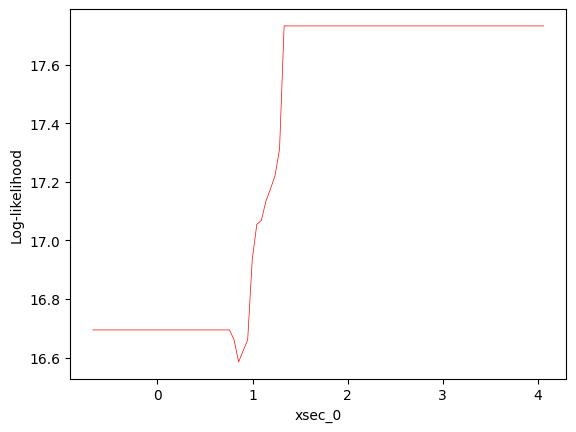

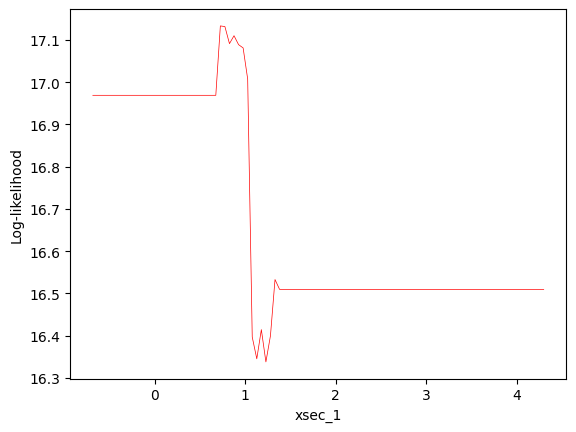

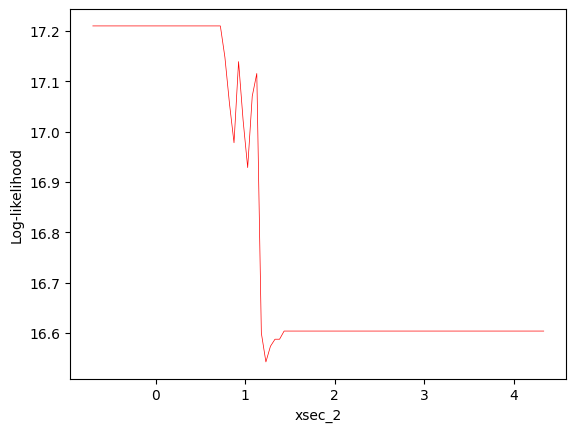

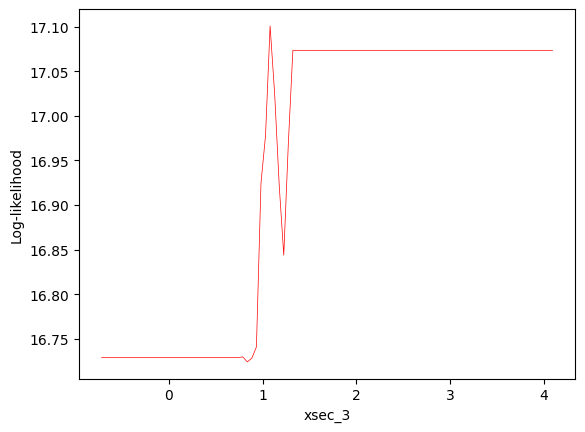

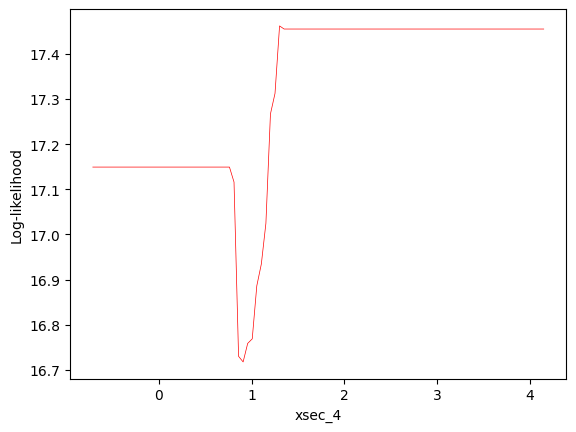

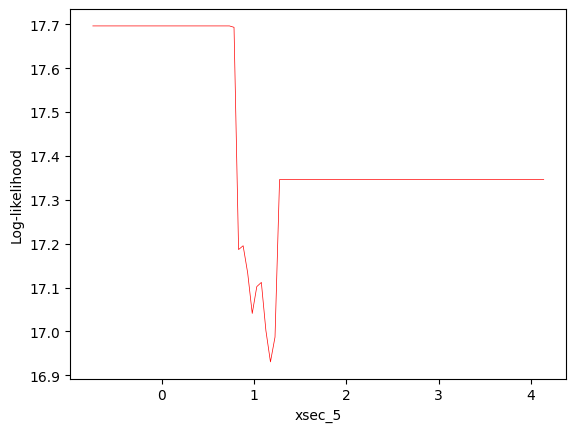

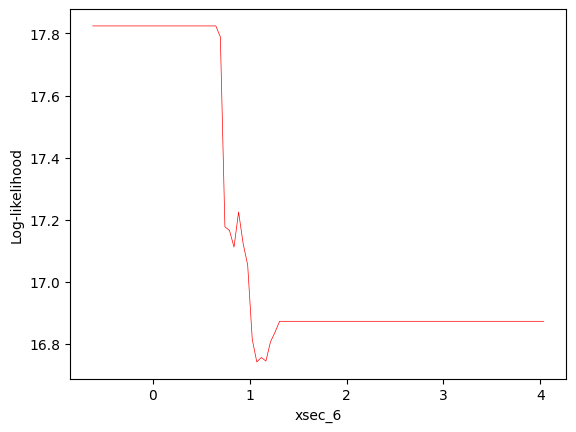

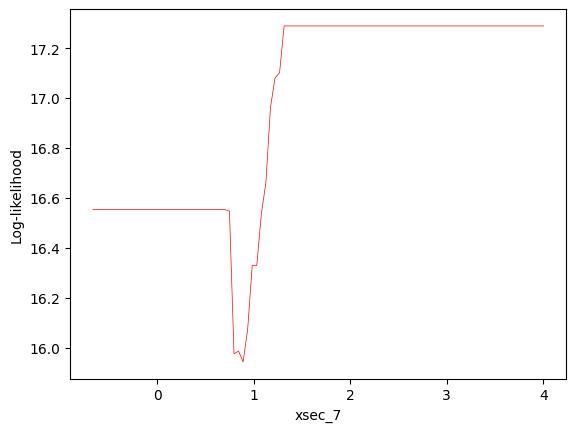

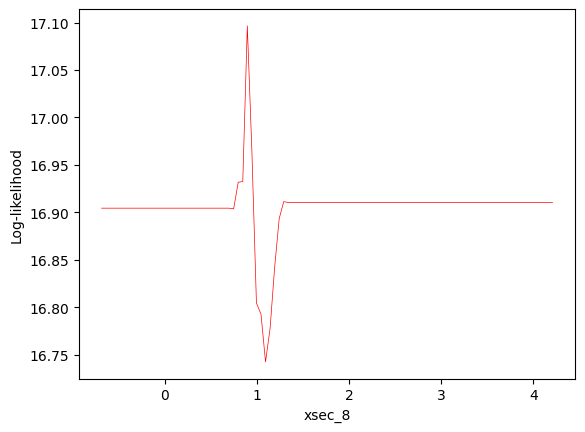

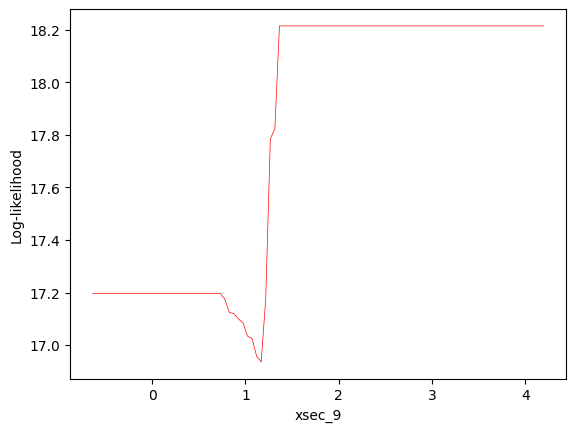

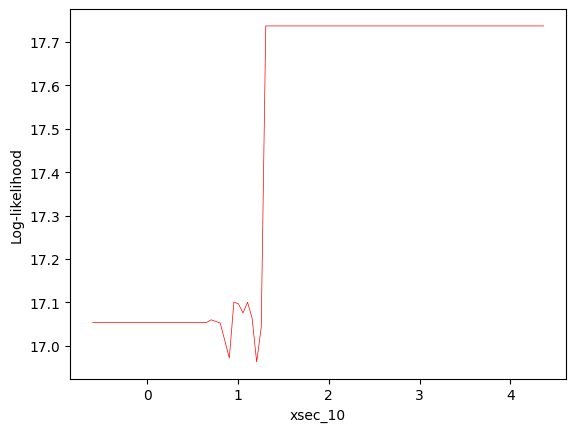

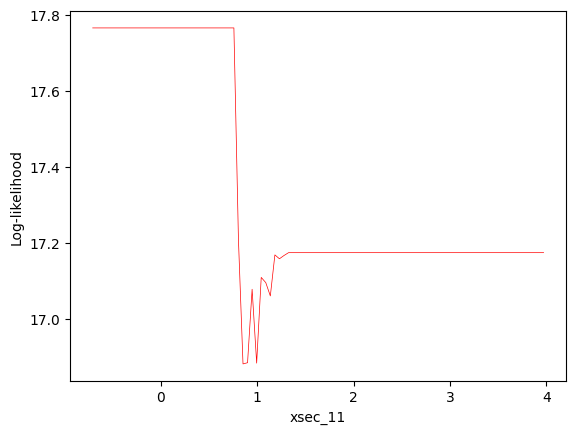

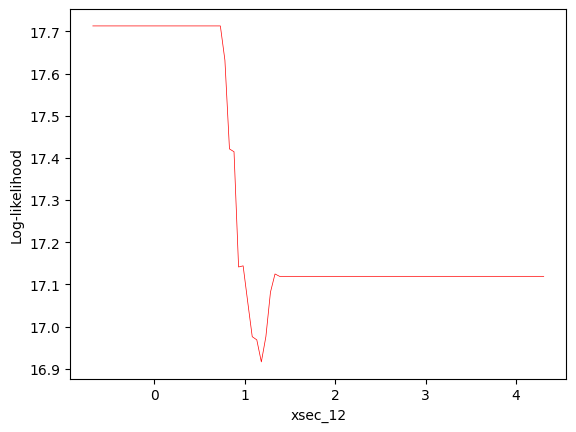

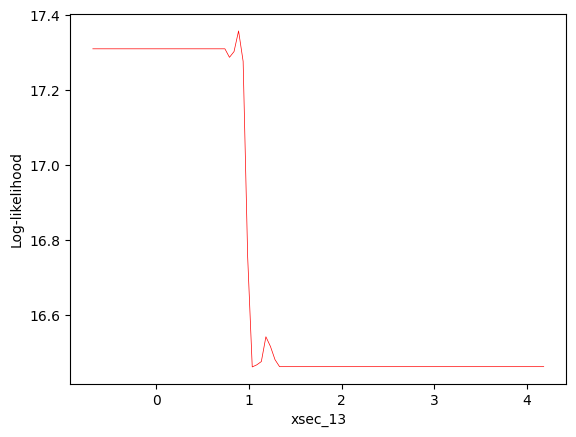

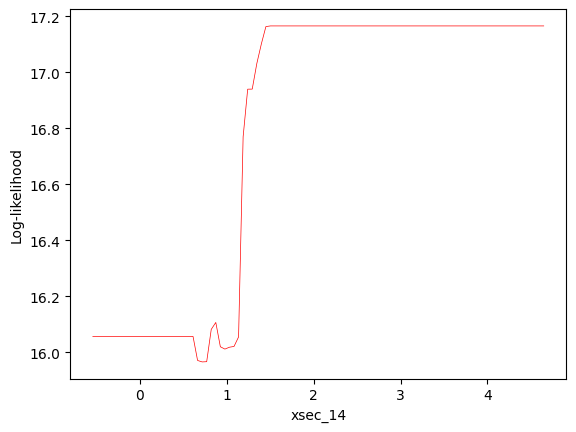

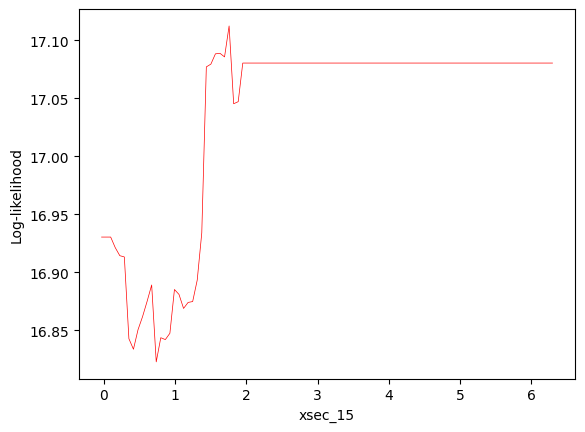

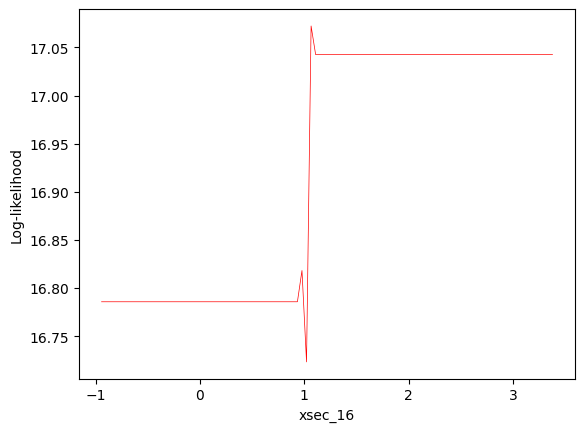

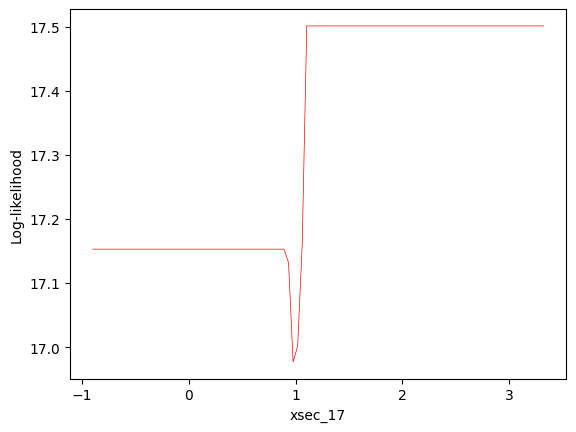

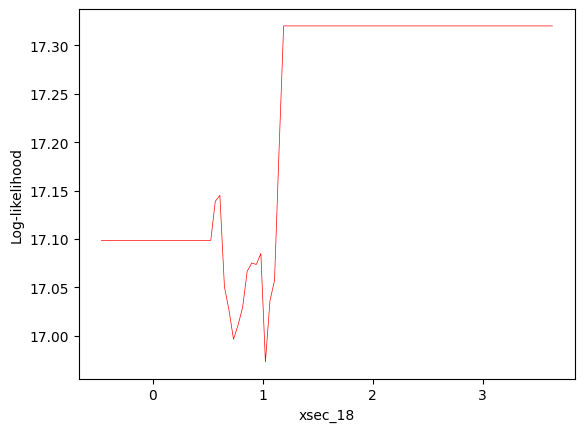

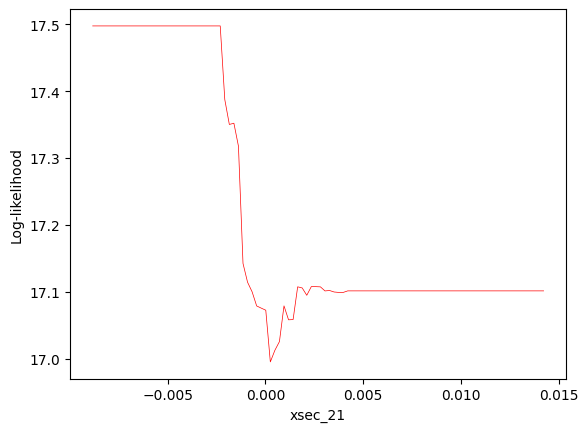

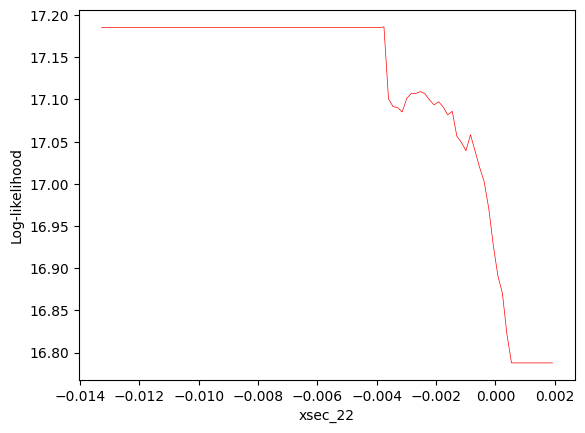

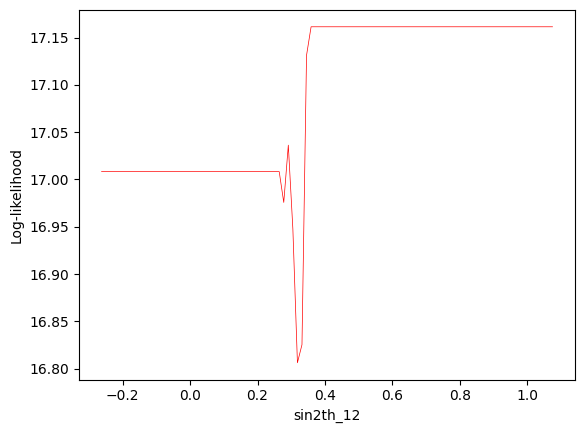

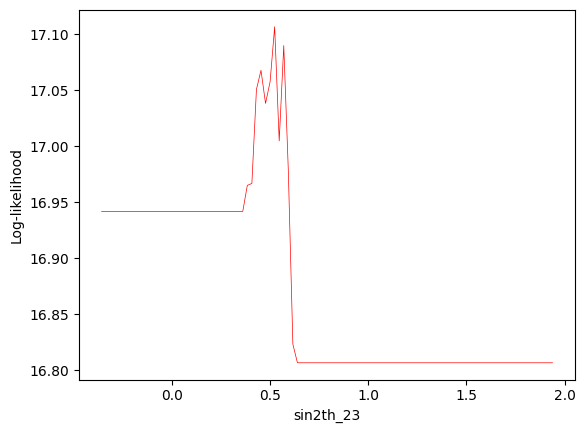

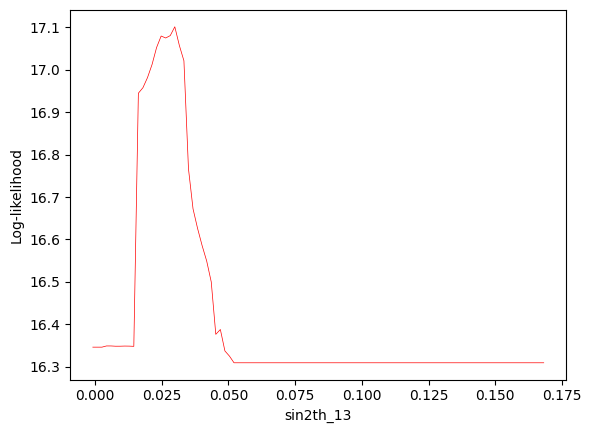

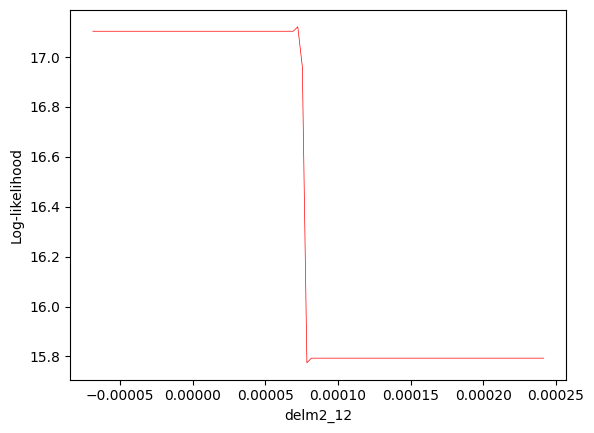

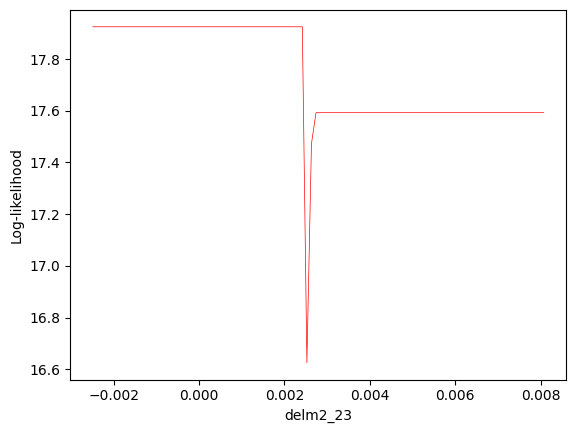

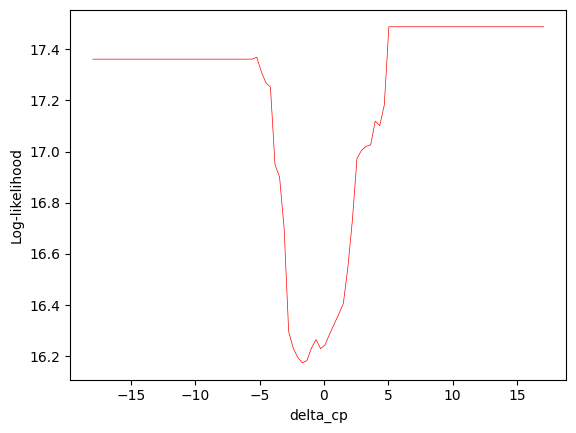

In [20]:
#testing a likelihood scan
#<Get initial value as you would for MCMC>
def likelihood_scan(n_points,n_params,start_step,lower_bounds,upper_bounds,param_names,linecolor):
    likelihoods = np.empty((n_params, n_points))
    for p in range(n_params):
        vals = np.linspace(lower_bounds[p], upper_bounds[p], n_points) 
        #print(vals)
        for i, v in enumerate(vals):
            curr_val = start_step.copy()
            curr_val[p] = v
            curr_l = ml_model.model_predict_unscale(curr_val.reshape(1, -1))
            likelihoods[p][i] = curr_l

        file_save = '/Users/lucie/Documents/Summer25/MaCh3-PythonUtils/notebooks/likelihood_scans/'
        fig, (trace_ax) = plt.subplots(nrows=1, ncols=1)
        trace_ax.plot(vals, likelihoods[p], linewidth=0.5, color=linecolor)
        trace_ax.set_ylabel('Log-likelihood')
        trace_ax.set_xlabel(f'{param_names[p]}')
        plt.show()
        fig.savefig(file_save+param_names[p]+'_like_scan.pdf',format='pdf')
        
        #return likelihoods

n_points=100
start_step = training_data.iloc[0].to_numpy() #but this has 29 items
n_params = len(start_step)
param_names = list(training_data.columns)

min_bc = min_no.copy()-(2*min_no*np.sign(min_no))
max_bc = max_no.copy()+(2*max_no*np.sign(max_no))

print('### NO Likelihood Scans ###')
likelihood_scan(n_points,n_params,start_step,min_bc,max_bc,param_names,linecolor='r')
#print('### IO Likelihood Scans ###')
#likelihood_scan(n_points,n_params,start_step,min_io,max_io,param_names,linecolor='b')

In [15]:
#do MCMC on the params
mcmc_chain, mcmc_log_like = v2_run_mcmc(ml_model,training_data,min_no,max_no,min_io,max_io)
#THEN WE CAN RUN THIS MORE OFTEN TO DEBUG THE SCALING ISSUES 

  0%|          | 0/1000 [00:00<?, ?it/s]



### 0 Chain ###
in bound count: 0.0
out bound count: 0.0
accept count: 937.0
reject count: 63.0


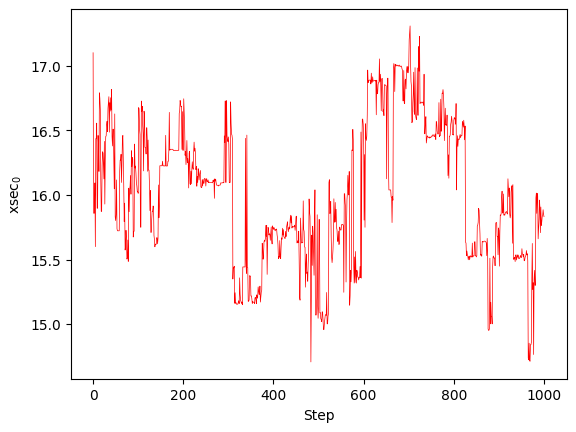

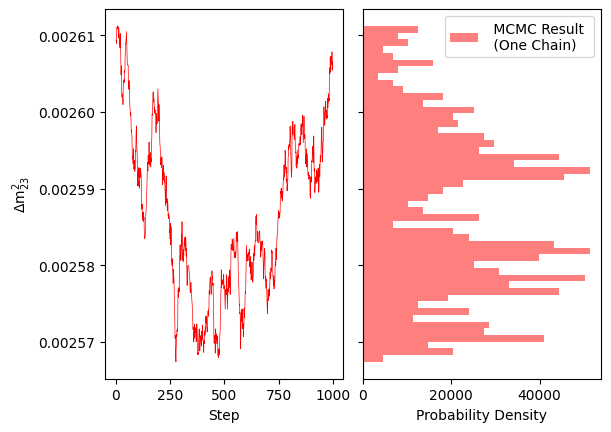

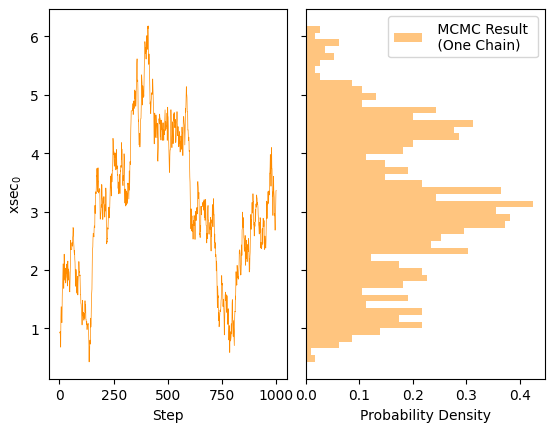

In [16]:
#likelihood trace plot
#print(mcmc_log_like[:,:,0])
cutoff = 1

x_0_like = mcmc_log_like[:,0,0].flatten()
fig, (trace_ax) = plt.subplots(nrows=1, ncols=1)
x_vals = np.arange(0,len(x_0_like),1)
trace_ax.plot(x_vals, x_0_like, linewidth=0.5, color='r')
trace_ax.set_ylabel(r'$\text{xsec}_0$')
trace_ax.set_xlabel('Step')

#test of non-combined chains
x_0 = mcmc_chain[:,0,0][cutoff:].flatten()
#print(x_0)
delM_values = mcmc_chain[:,0,25][cutoff:].flatten() #apply same thing to the og data to compare

fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
x = np.arange(0,len(delM_values),1)
trace_ax.plot(x, delM_values, linewidth=0.5, color='r')
trace_ax.set_ylabel(r'$\Delta \text{m}^2_{23}$')
trace_ax.set_xlabel('Step')
##
post_ax.hist(delM_values, bins=50, color='r', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (One Chain)')
post_ax.set_xlabel('Probability Density')
# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
fig.subplots_adjust(wspace=.08)
post_ax.legend()
plt.show()

figA, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
x = np.arange(0,len(x_0),1)
trace_ax.plot(x, x_0, linewidth=0.5, color='darkorange')
trace_ax.set_ylabel(r'$\text{xsec}_{0}$')
trace_ax.set_xlabel('Step')
##
post_ax.hist(x_0, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (One Chain)')
post_ax.set_xlabel('Probability Density')
# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
figA.subplots_adjust(wspace=.08)
post_ax.legend()
plt.show()

ValueError: autodetected range of [nan, nan] is not finite

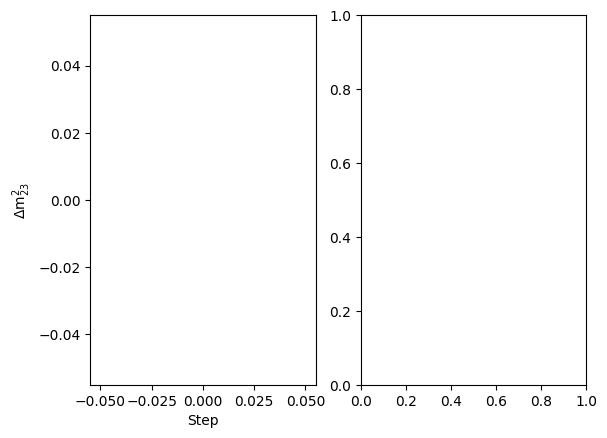

In [29]:
cutoff = 200 #minimum burn in cutoff
file_save_path = '/Users/lucie/Documents/Summer25/MaCh3-PythonUtils/notebooks/output_plots/'
x_0 = mcmc_chain[:,:,0][cutoff:,:].flatten()
delM_values = mcmc_chain[:,:,25][cutoff:,:].flatten() #apply same thing to the og data to compare

fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
x = np.arange(0,len(delM_values),1)
trace_ax.plot(x, delM_values, linewidth=0.5, color='r')
trace_ax.set_ylabel(r'$\Delta \text{m}^2_{23}$')
trace_ax.set_xlabel('Step')
##
post_ax.hist(delM_values, bins=50, color='r', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (Combined Chains)')
post_ax.set_xlabel('Probability Density')
# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
fig.subplots_adjust(left=0.15,wspace=.08)
post_ax.legend()
fig.savefig(file_save_path+'delm2_23.pdf',format='pdf')
plt.show()

figA, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
x = np.arange(0,len(x_0),1)
trace_ax.plot(x, x_0, linewidth=0.5, color='darkorange')
trace_ax.set_ylabel(r'$\text{xsec}_{0}$')
trace_ax.set_xlabel('Step')
##
post_ax.hist(x_0, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (Combined Chains)')
post_ax.set_xlabel('Probability Density')
# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
figA.subplots_adjust(left=0.13,wspace=.1)
post_ax.legend()
figA.savefig(file_save_path+'xsec_0.pdf',format='pdf')
plt.show()

og_hist = training_data.iloc[:,25][cutoff:]
#og_hist = [val for val in og_hist if val>0] #use this if we are NOT FLIPPING
bin_vals = np.linspace(min(og_hist),max(og_hist),50)
#print(og_hist)
fig2, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(delM_values, bins=bin_vals, color='r', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (Combined Chains)')
ax.hist(og_hist, bins=bin_vals, color='b', alpha=0.5, orientation='horizontal', density=True, label='Training Data')
ax.set_xlabel('Probability Density')
ax.set_ylabel(r'$\Delta \text{m}^2_{23}$')
fig2.subplots_adjust(left=0.15)
ax.legend()
fig2.savefig(file_save_path+'delm2_23_training_comparison.pdf',format='pdf')
plt.show()

ttree_table = get_table_hacky()
#print(ttree_table)
desired_col = ttree_table.iloc[:,25][cutoff:]
#desired_col = [val for val in desired_col if val>0] #use this if we are NOT FLIPPING
bin_vals = np.linspace(min(desired_col),max(desired_col),50)

fig3, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(delM_values, bins=bin_vals, color='r', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (Combined Chains)')
ax.hist(desired_col, bins=bin_vals, color='#00A36C', alpha=0.5, orientation='horizontal', density=True, label='Original MCMC Fit')
ax.set_xlabel('Probability Density')
ax.set_ylabel(r'$\Delta m^2_{23}$')
ax.legend()
fig3.subplots_adjust(left=0.15)
fig3.savefig(file_save_path+'delm2_23_mcmc_comparison.pdf',format='pdf')
plt.show()


In [62]:
# print("### Combined Mass Orderings ### \n")
# plt.hist(delM_values, bins=100, color='b', alpha=0.5, orientation='vertical', density=True)
# plt.ylabel('Probability Density')
# plt.xlabel(r'$\Delta m^2_{23}$')

In [9]:
#BAYES FACTOR ANALYSIS
do_bayes_factor(desired_col,label="Original MCMC fit") #turn off if NOT FLIPPING
do_bayes_factor(delM_values,label="BDT ML Output") #cus they error when we /0

Original MCMC fit Bayes' factor: 0.449
BDT ML Output Bayes' factor: 0.487


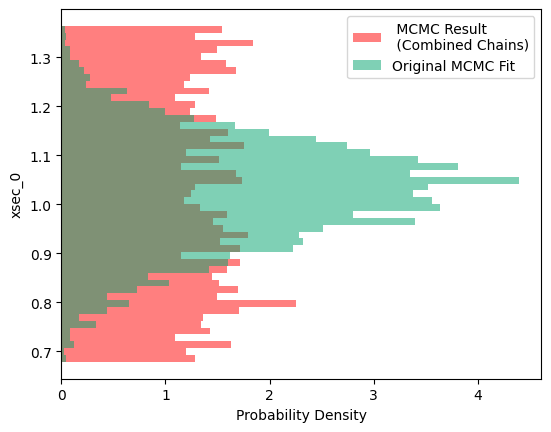

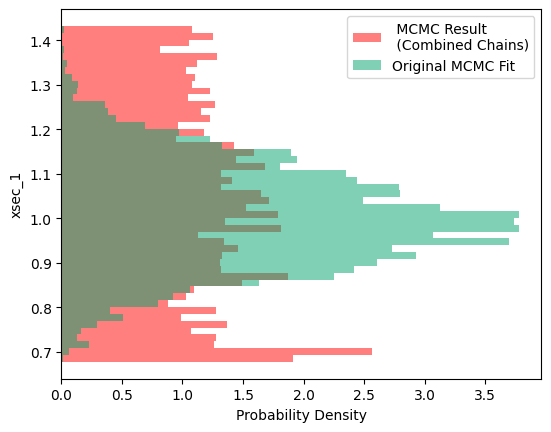

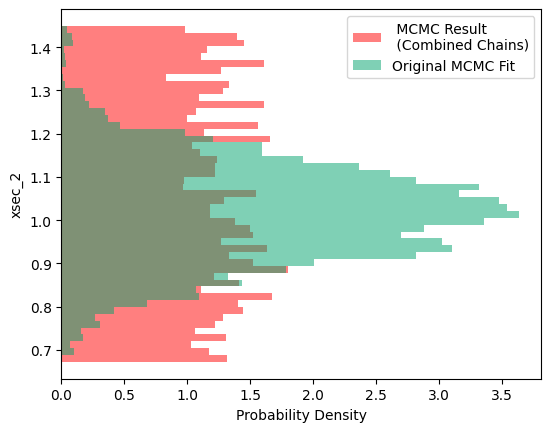

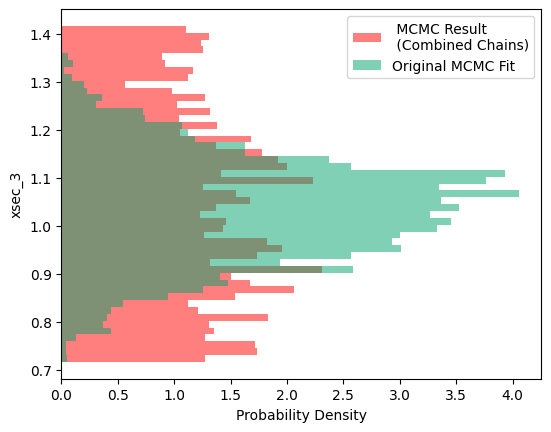

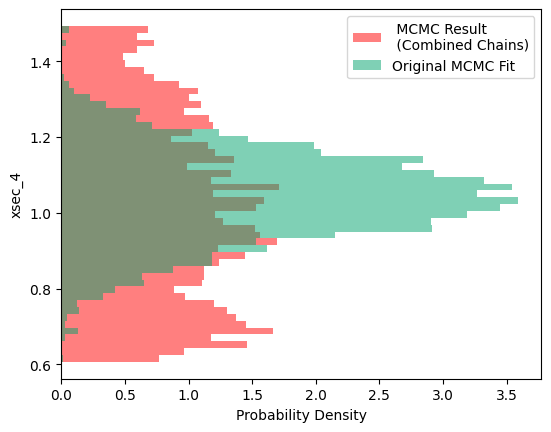

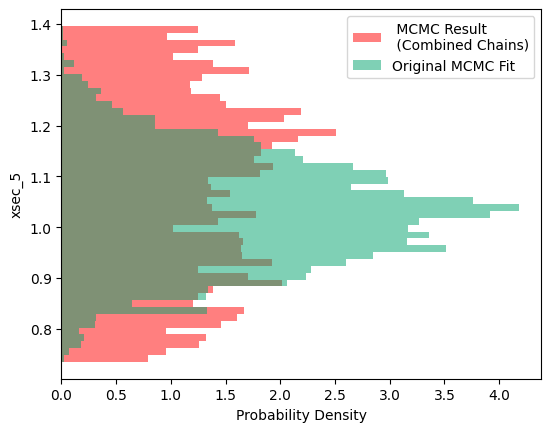

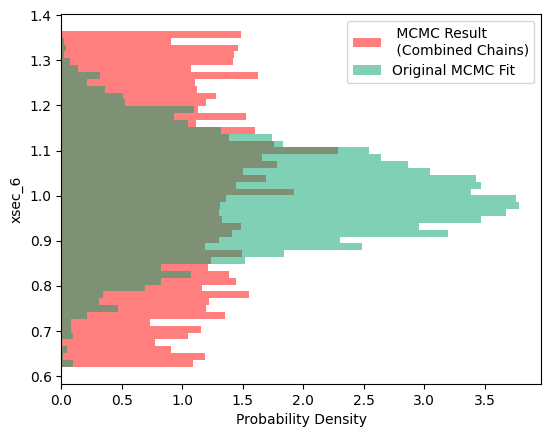

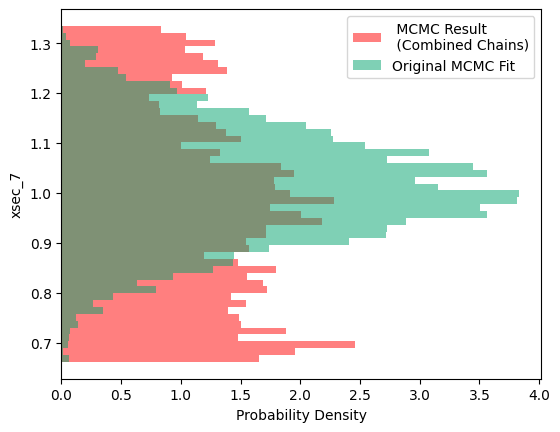

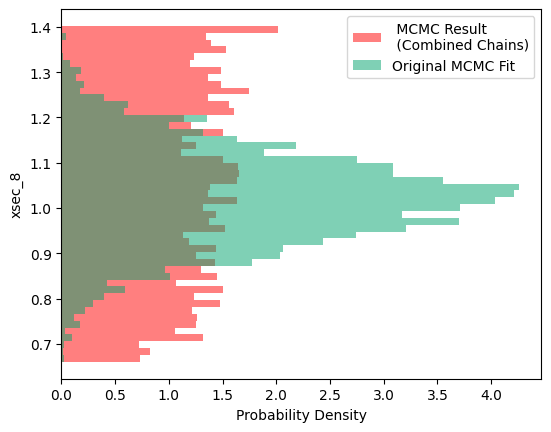

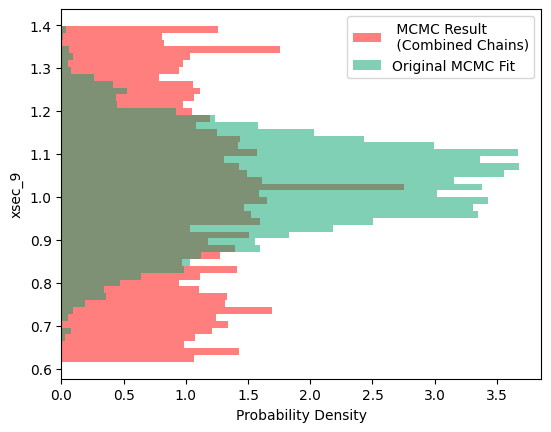

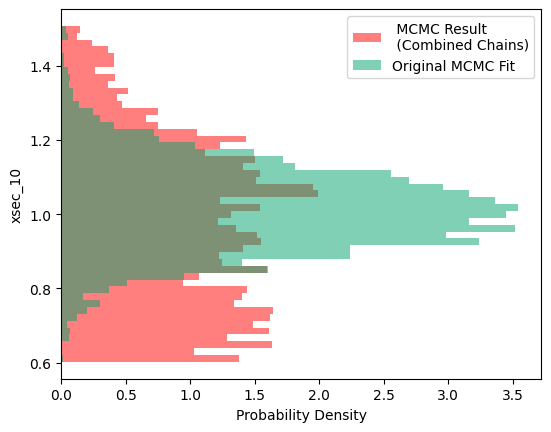

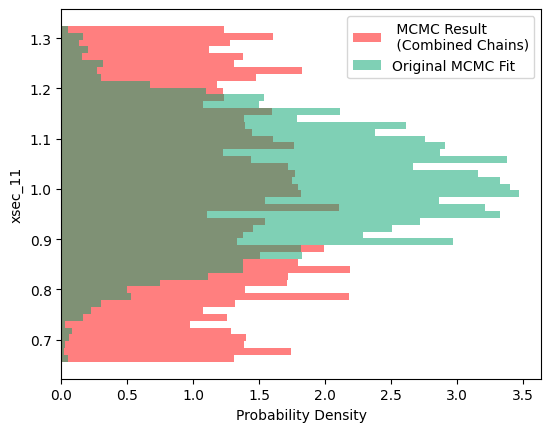

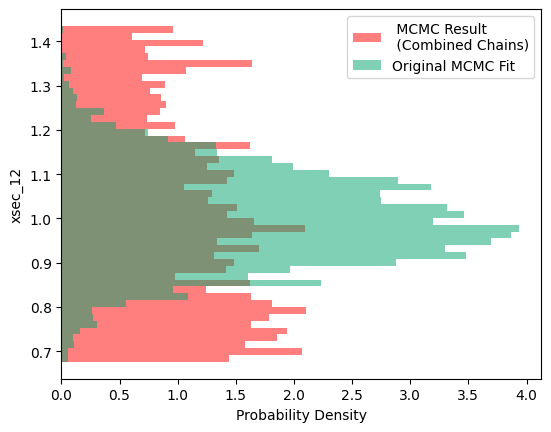

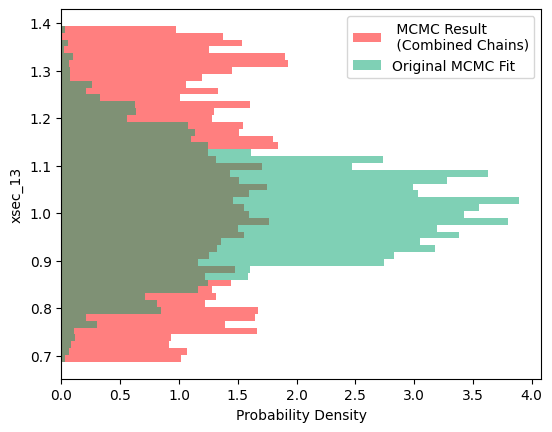

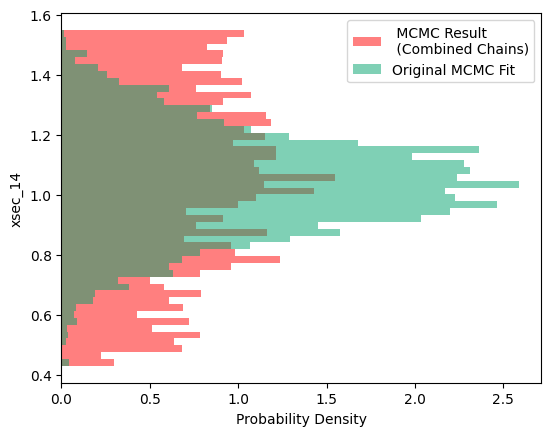

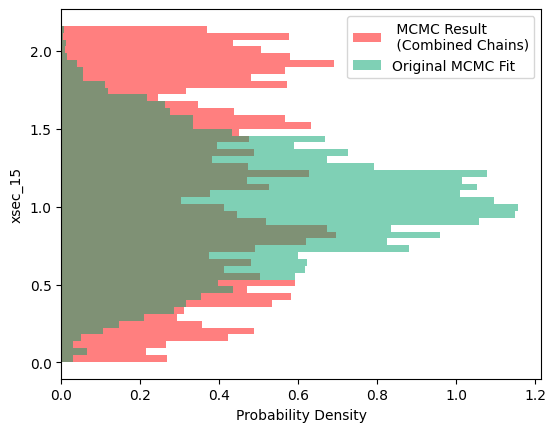

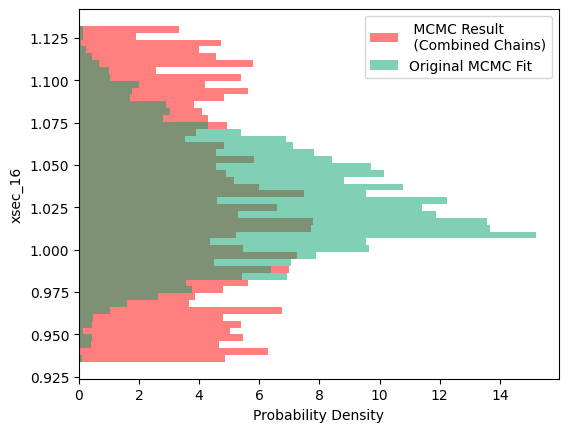

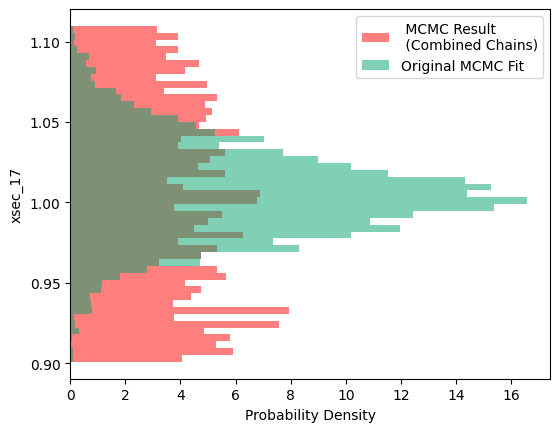

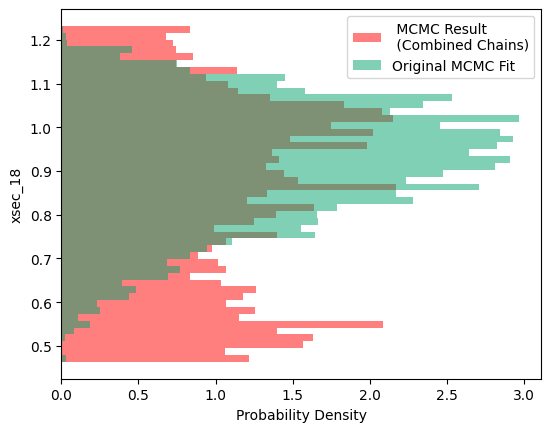

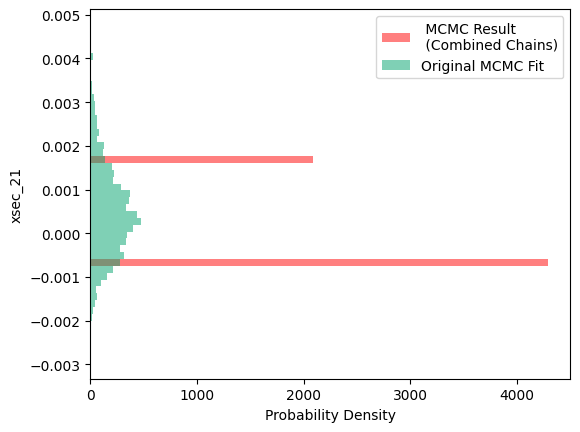

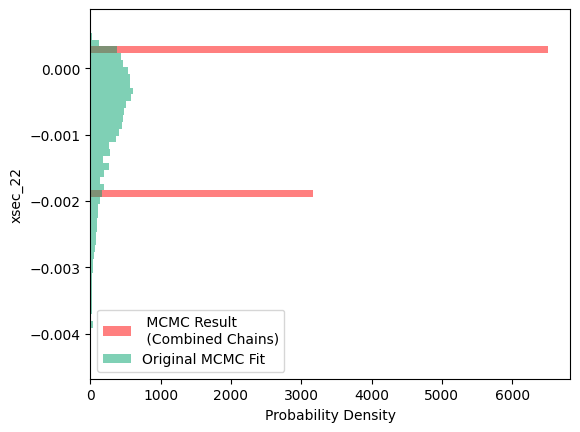

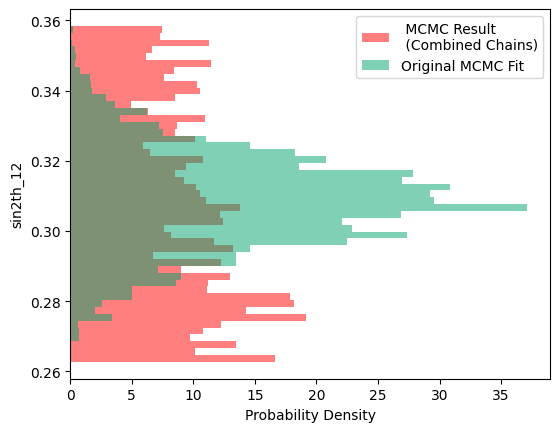

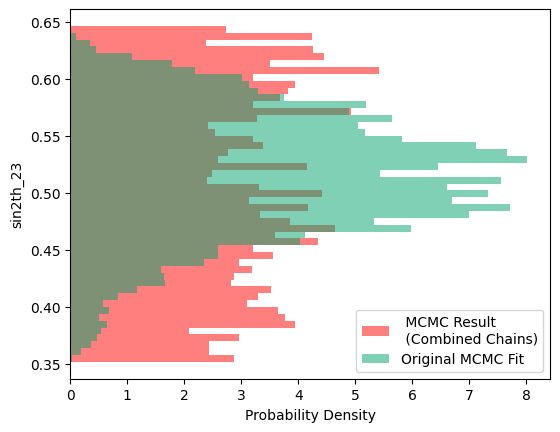

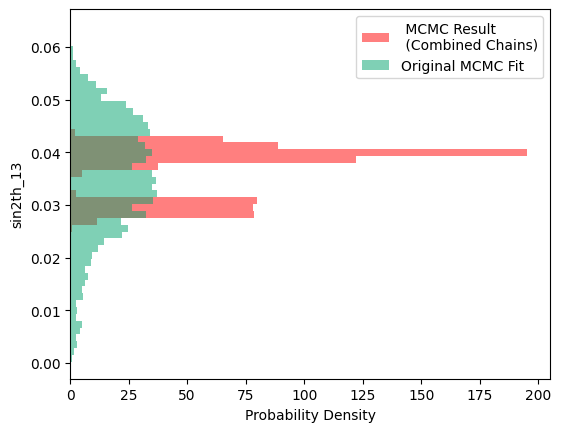

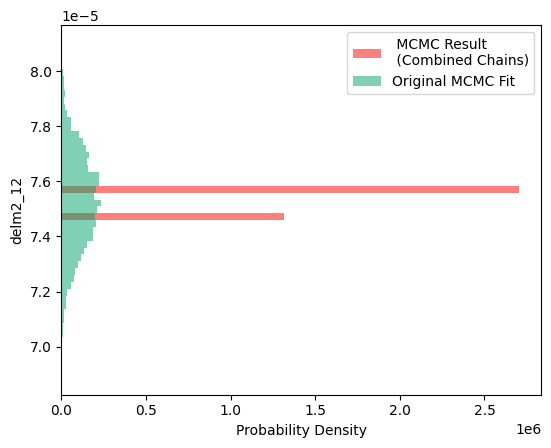

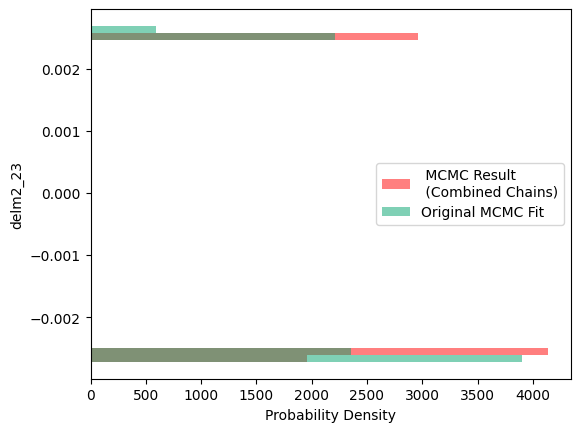

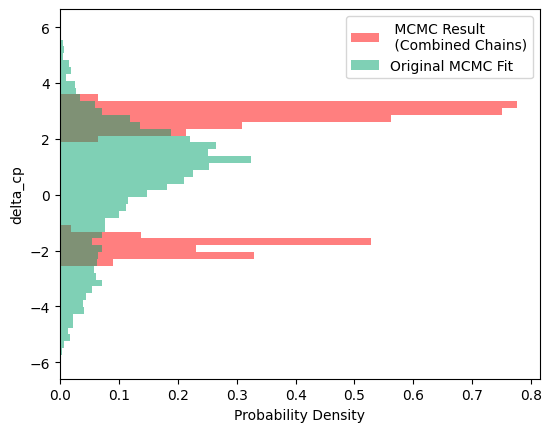

In [10]:
param_names = list(ttree_table.columns)
for p in range(0,27):
    #mcmc_col = [m[p] for m in mcmc_chain]
    mcmc_col = mcmc_chain[:,:,p][cutoff:,:].flatten()
    ttree_col = ttree_table.iloc[:,p][cutoff:]
    bin_vals = np.linspace(min(ttree_col),max(ttree_col),50)

    fig, ax = plt.subplots(nrows=1, ncols=1)
    ax.hist(mcmc_col, bins=bin_vals, color='r', alpha=0.5, orientation='horizontal', density=True, label=' MCMC Result \n (Combined Chains)')
    ax.hist(ttree_col, bins=bin_vals, color='#00A36C', alpha=0.5, orientation='horizontal', density=True, label='Original MCMC Fit')
    ax.set_xlabel('Probability Density')
    ax.set_ylabel(f'{param_names[p]}')
    ax.legend()
    fig.subplots_adjust(left=0.15)
    fig.savefig(file_save_path+f'{param_names[p]}_hist.pdf',format='pdf')
    plt.show()

In [ ]:
#def ml_test_function(mass_cut):
    # chain_handler = 0
    # # Set up file properties
    # chain_name = 'posteriors'
    # verbose=False

    # chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
    # # Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
    # chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])
    # # Now we add parameters we care about. Note this only need to be a substring of the full name
    # chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
    # # The fitting label is special, it's the thing we want to train our network to predict
    # fitting_label = "LogL"
    # # We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
    # chain_handler.add_additional_plots(fitting_label, True)

    # #specify the cut for the mass being tested
    # chain_handler.add_new_cuts([mass_cut, "LogL_systematic_xsec_cov<1234", "step>10000"])
    # chain_handler.convert_ttree_to_array()
    
    # model_output=Path("../models/my_model")
    # # Make sure the model output directory exists
    # model_output.parent.mkdir(parents=True, exist_ok=True)
    # The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
    # ml_factory = MLFactory(chain_handler, fitting_label, f"{model_output}.pdf")
    
    # #Initialise the model here
    # ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', max_iter=10000, verbose=1, max_leaf_nodes=40) 
    # # Let's use 20% of the data for testing 
    # ml_model.set_training_test_set(0.2)
    # #setup to perform a grid search of scikit params
    # param_grid = {
    #     "learning_rate":(0.001,0.01,0.1,1),
    #     "max_leaf_nodes":(50,100,200)
    # }
    # grid_search = RandomizedSearchCV(estimator=HistGradientBoostingRegressor(), param_distributions=param_grid, n_iter=10)
    # training_data = ml_model.training_data #all x_sec columns etc
    # target_data = ml_model._training_labels #log-likelihood 

    #Do the grid search over the training data
    # grid_search.fit(training_data, target_data)
    # fit_params = grid_search.best_params_
    # print("Best params found by grid search:")
    # print(fit_params)

    # max_leaves = fit_params['max_leaf_nodes']
    # lr = fit_params['learning_rate']

    # ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', 
    #                                     max_iter=10000, verbose=1, max_leaf_nodes=max_leaves, learning_rate=lr) 
    
    # #train the ML model
    # ml_model.set_training_test_set(0.2)
    # ml_model.train_model()
    
    # #do MCMC on the params
    # mcmc_chain, delM_log_like = v2_run_mcmc(ml_model,training_data)
    # #from the chain results, plot trace and histogram of M23
    # delM_values =  []
    # inv_stored_steps = [ml_model.invert_scaling(s.reshape(1,-1)) for s in mcmc_chain]
    # #want item 27 for delm2_23 column's values
    # for i in inv_stored_steps:
    #     delM_values.append(i[0][27])

    # fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
    # x = np.arange(0,len(delM_values),1)
    # trace_ax.plot(x, delM_values, linewidth=0.5, color='darkorange')
    # trace_ax.set_ylabel(r'$\Delta m^2_{23}$')
    # trace_ax.set_xlabel('Step')
    # ##
    # post_ax.hist(delM_values, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True)
    # post_ax.set_xlabel('Probability Density')
    # # Merge the two axes
    # plt.setp(post_ax.get_yticklabels(), visible=False)
    # fig.subplots_adjust(wspace=.08)
    # plt.show()

    # #make train and test plots for the ML model for completeness
    # ml_model.test_model()

    # #print('done')
    # return delM_values, delM_log_like


#function to find and assign BCs to the parameters
#NEED TO EDIT THIS TO ACCOUNT FOR THE COMBO MASS SYSTEM
#def boundary_con(start_step,training_data):
    # n = len(start_step)
    # min_bc = []
    # max_bc = []

    # for i in range(n):
    #     column = training_data.iloc[:,i].to_numpy() 
    #     min_col_val = np.min(column)
    #     max_col_val = np.max(column)
    #     #adapt to include -+ 10% interval to the BCs in next test
    #     min_bc.append(min_col_val-(0.1*min_col_val))
    #     max_bc.append(max_col_val+(0.1*max_col_val))

    # return np.array(min_bc), np.array(max_bc)

# #function to do MCMC for the parameters
# def v2_run_mcmc(ml_model,training_data,NO_min_BCs,NO_max_BCs,IO_min_BCs,IO_max_BCs):
#     NSTEPS: int = 10000

#     start_step = training_data.iloc[0].to_numpy() #but this has 29 items 
#     stored_steps = np.empty(NSTEPS+1, dtype=object)

#     step_sizes = np.ones(len(start_step))*0.01

#     stored_steps[0] = start_step #so this initialises with 29 items
#     #so when we accept new points we need to have all parameters considered and their new values included

#     current_L = ml_model.model_predict_single_sample(start_step)
#     stored_L = np.empty(NSTEPS+1, dtype=object)
#     stored_L[0] = current_L

#     #lower, upper = boundary_con(start_step,training_data) #load in boundary conditions on the params

#     for s in range(NSTEPS):
#         x_t = stored_steps[s]    
#         new_priors = np.random.normal(x_t, step_sizes)
#         proposed_L = ml_model.model_predict_single_sample(new_priors) #returns logL based on new set of priors

#         for idx, param in enumerate(new_priors): #use this to sort when BCs are applied
#             #filter for NO and IO BCs separately to accept
#             if (param<NO_max_BCs[idx] and param>NO_min_BCs[idx]) or (param<IO_max_BCs[idx] and param>IO_min_BCs[idx]):
#                 accept_prob = proposed_L/current_L #likelihood ratio based on new and old set of priors
                
#             else:
#                 accept_prob = 0
        
#         #accept_prob = proposed_L/current_L #use just this for non-BC applied
#         u = np.random.uniform(0,1) #uniform dist of u to compare to acceptance prob

#         if u <= accept_prob: #accept proposal
#             stored_steps[s+1] = new_priors
#             current_L = proposed_L
            
#         if u > accept_prob: #reject proposal
#             stored_steps[s+1] = stored_steps[s]

#         stored_L[s+1] = current_L #update log-likelihood

#     return stored_steps, stored_L

### Normal Ordering Results ### 

Attempting to open ..\models\demo_chain.root
Succesfully opened ..\models\demo_chain.root:posteriors
Best params found by grid search:
{'max_leaf_nodes': 100, 'learning_rate': 0.1}
Training Model
Binning 0.005 GB of training data: 0.066 s
Binning 0.001 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 1908 trees in 49.143 s, (190800 total leaves)
Time spent computing histograms: 11.280s
Time spent finding best splits:  11.398s
Time spent applying splits:      5.814s
Time spent predicting:           0.309s


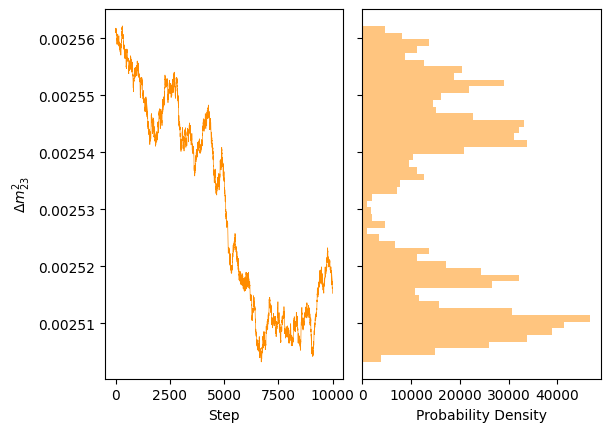

Training Results!

Mean Absolute Error : 0.030754976447918726

Line of best fit : y=1.0246590769276058x + 0.008282238843074845

Saving QQ to train_qq_plot.pdf

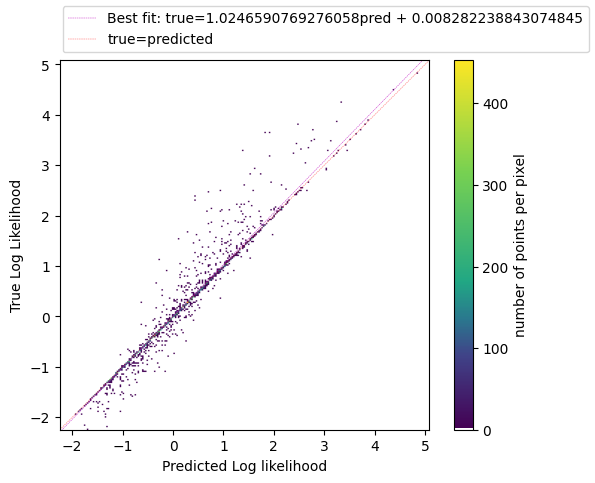

mean: 0.008082921460969124, std dev: 0.13743686446224887

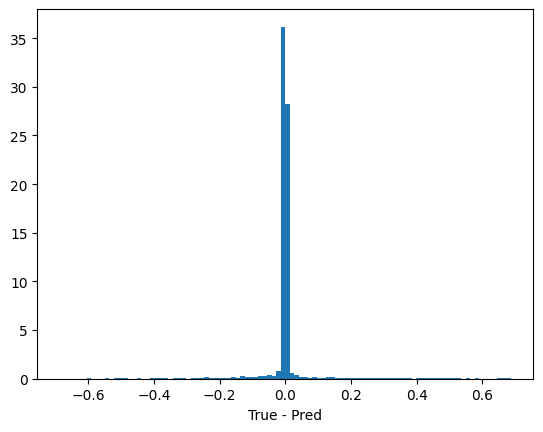

=====

Testing Results!

Mean Absolute Error : 0.04274274503959134

Line of best fit : y=1.0308345123619183x + 0.013360600534191866

Saving QQ to .pdf

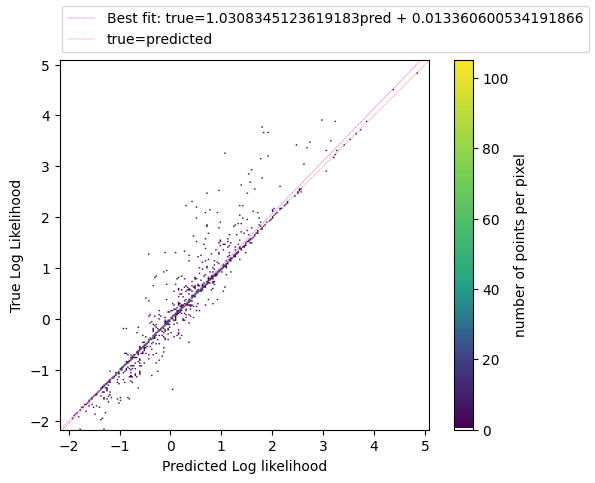

mean: 0.012825820358583387, std dev: 0.1693635453404808

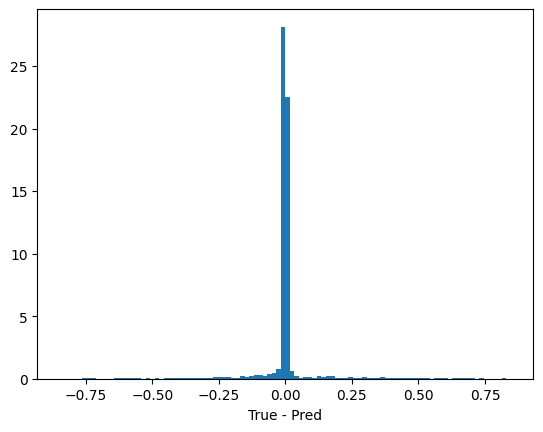

=====



### Inverted Ordering Results ### 

Attempting to open ..\models\demo_chain.root
Succesfully opened ..\models\demo_chain.root:posteriors
Best params found by grid search:
{'max_leaf_nodes': 200, 'learning_rate': 0.1}
Training Model
Binning 0.012 GB of training data: 0.096 s
Binning 0.001 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 2908 trees in 169.306 s, (581600 total leaves)
Time spent computing histograms: 41.792s
Time spent finding best splits:  39.096s
Time spent applying splits:      20.968s
Time spent predicting:           1.093s


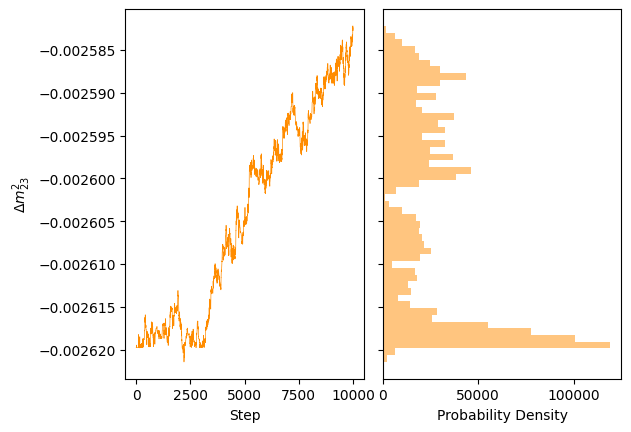

Training Results!

Mean Absolute Error : 0.021742618082642235

Line of best fit : y=1.0188227322224483x + 0.0072428016476272375

Saving QQ to train_qq_plot.pdf

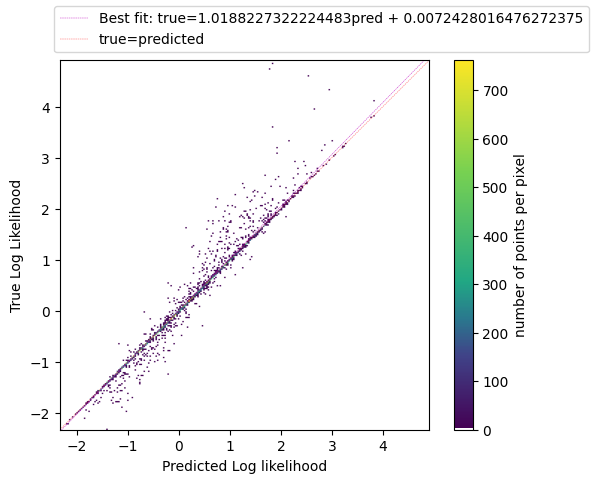

mean: 0.007108991013410034, std dev: 0.11710531029207388

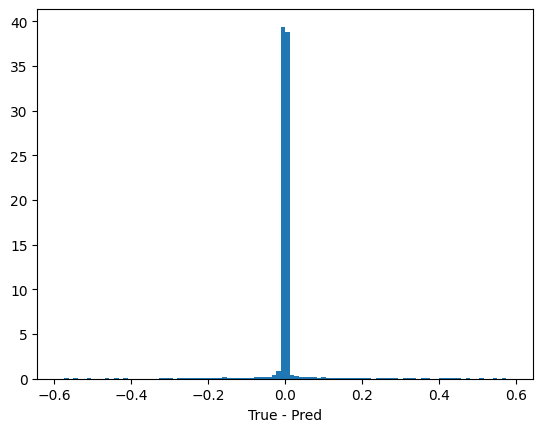

=====

Testing Results!

Mean Absolute Error : 0.026644343912951104

Line of best fit : y=1.0207489016759956x + 0.00855791617160077

Saving QQ to .pdf

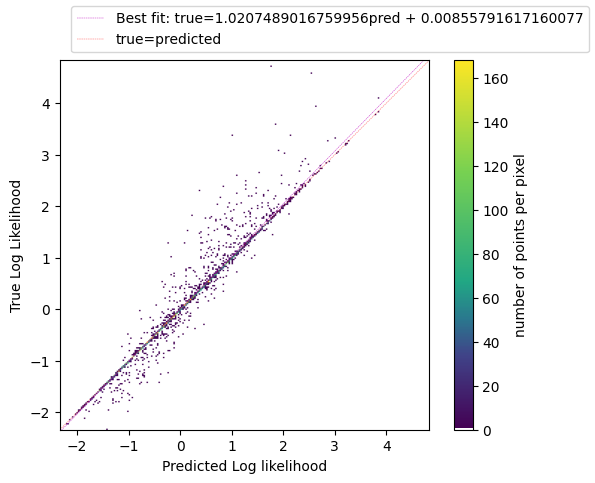

mean: 0.008300463186050915, std dev: 0.12994553109626053

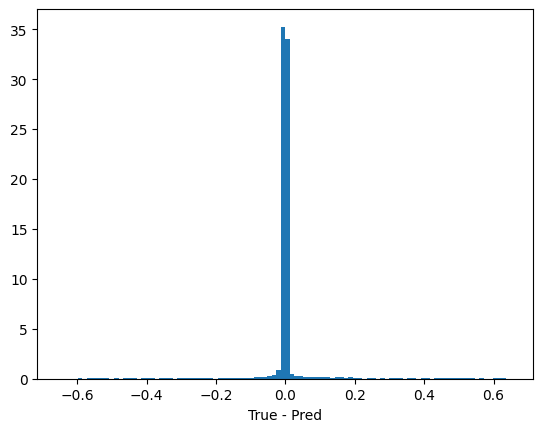

=====

### Combined Mass Orderings ### 



Text(0.5, 0, '$\\Delta m^2_{23}$')

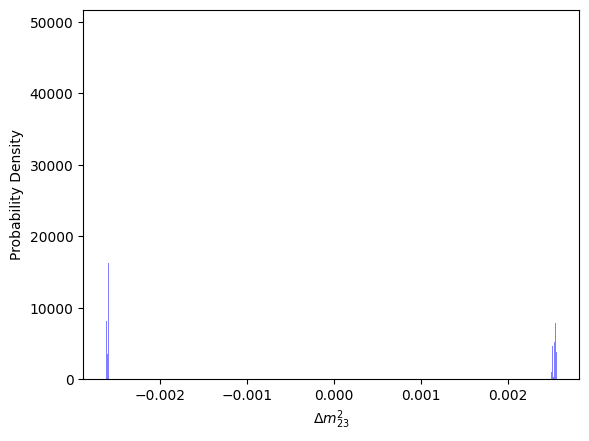

In [ ]:
# #from here we're going to do it separately for the NO and IO mass chains
# NO_cut = "delm2_23>0"
# IO_cut = "delm2_23<0"

# print("### Normal Ordering Results ### \n")
# M23_NO, M23_log_likelihood = ml_test_function(NO_cut) #run function for normal ordering
# print("\n")
# print("### Inverted Ordering Results ### \n")
# M23_IO, M23I_log_likelihood = ml_test_function(IO_cut) #run function for inverted ordering

# #test joined mass combo array
# M23_NO = np.array(M23_NO)
# M23_IO = np.array(M23_IO)
# masses = np.concatenate([M23_NO,M23_IO])
# print("### Combined Mass Orderings ### \n")
# plt.hist(masses, bins=5000, color='b', alpha=0.5, orientation='vertical', density=True)
# plt.ylabel('Probability Density')
# plt.xlabel(r'$\Delta m^2_{23}$')



Let's quickly use the chain handler to make a plot of the trace and posterior!

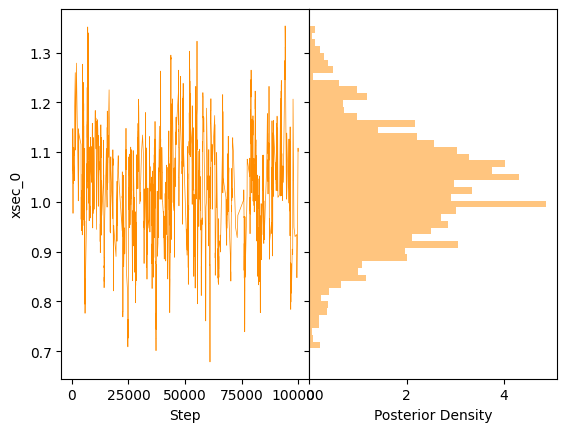

In [ ]:
# We're just grab the first column of our pandas dataframe
#parameter_vals = chain_handler.ttree_array.iloc[:,0]
# Grab the name from column label
#param_label = chain_handler.ttree_array.columns[0]

# Setup figure
#fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)

# Plot traces
#trace_ax.plot(parameter_vals, linewidth=0.5, color='darkorange')

# Plot posterior
#post_ax.hist(parameter_vals, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True)

# Merge the two axes
#plt.setp(post_ax.get_yticklabels(), visible=False)
#fig.subplots_adjust(wspace=.0)

# Set the axis labels
#trace_ax.set_xlabel("Step")
#post_ax.set_xlabel("Posterior Density")
#trace_ax.set_ylabel(param_label)

#plt.show()

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [ ]:
# First step we need to initialise the factory
#from pathlib import Path


#model_output=Path("../models/my_model")
# Make sure the model output directory exists
#model_output.parent.mkdir(parents=True, exist_ok=True)

# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
#ml_factory = MLFactory(chain_handler, fitting_label, f"{model_output}.pdf")

Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [ ]:
#Initialise the model here
#ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', max_iter=10000, verbose=1, max_leaf_nodes=40) 
# Let's use 20% of the data for testing 
#ml_model.set_training_test_set(0.2)

#fuck around with the loss type, learning rate, max leaf nodes (up to 100/200 even), l2_regularization, max_bins
#look at printing out the loss function for each step as well
#apply the grid search across some of these params above to iteratively test them out in the interface
#param_grid = {
 #   "learning_rate":(0.001,0.01,0.1,1),
  #  "max_leaf_nodes":(50,100,200)
#}
#grid_search = RandomizedSearchCV(estimator=HistGradientBoostingRegressor(), param_distributions=param_grid, n_iter=10)
#training_data = ml_model.training_data #all x_sec columns etc
#target_data = ml_model._training_labels #log-likelihood 

#Do the grid search over the training data
#grid_search.fit(training_data, target_data)
#fit_params = grid_search.best_params_
#print("Best params found by grid search:")
#print(fit_params)

#max_leaves = fit_params['max_leaf_nodes']
#lr = fit_params['learning_rate']

#ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', 
 #                                    max_iter=10000, verbose=1, max_leaf_nodes=max_leaves, learning_rate=lr) 

Best params found by grid search:
{'max_leaf_nodes': 200, 'learning_rate': 0.1}


In [ ]:
#print(training_data.head)


In [ ]:
# Now we need to train our network
#ml_model.set_training_test_set(0.2)
#ml_model.train_model()

Training Model
Binning 0.005 GB of training data: 0.115 s
Binning 0.001 GB of validation data: 0.016 s
Fitting gradient boosted rounds:
Fit 1042 trees in 46.691 s, (208400 total leaves)
Time spent computing histograms: 10.173s
Time spent finding best splits:  9.740s
Time spent applying splits:      6.027s
Time spent predicting:           0.257s


In [ ]:
#def boundary_con(start_step):
 #   n = len(start_step)
  #  min_bc = []
   # max_bc = []

    #for i in range(n):
     #   column = training_data.iloc[:,i].to_numpy() 
      #  min_col_val = np.min(column)
       # max_col_val = np.max(column)
        #adapt to include -+ 10% interval to the BCs in next test
        #min_bc.append(min_col_val-(0.1*min_col_val))
        #max_bc.append(max_col_val+(0.1*max_col_val))

    #return np.array(min_bc), np.array(max_bc)

In [ ]:
#NSTEPS: int = 10000

#start_step = training_data.iloc[0].to_numpy() #but this has 29 items 
#stored_steps = np.empty(NSTEPS+1, dtype=object)

#step_sizes = np.ones(len(start_step))*0.01

#stored_steps[0] = start_step #so this initialises with 29 items
#so when we accept new points we need to have all parameters considered and their new values included

#current_L = ml_model.model_predict_single_sample(start_step)
#lower, upper = boundary_con(start_step) #load in boundary conditions on the params

#for m in range(NSTEPS):
    #x_t = stored_steps[m]    
    #new_priors = np.random.normal(x_t, step_sizes)
    #proposed_L = ml_model.model_predict_single_sample(new_priors) #returns logL based on new set of priors

    #for idx, param in enumerate(new_priors): #use this to sort when BCs are applied
        #if param < lower[idx] or param > upper[idx]:
       #     accept_prob = 0
      #  else:
     #       accept_prob = proposed_L/current_L #likelihood ratio based on new and old set of priors
    
    #accept_prob = proposed_L/current_L #use just this for non-BC applied
    #u = np.random.uniform(0,1) #uniform dist of u to compare to acceptance prob

    #if u <= accept_prob: #accept proposal
      #  stored_steps[m+1] = new_priors
     #   current_L = proposed_L
        
    #if u > accept_prob: #reject proposal
        #stored_steps[m+1] = stored_steps[m]




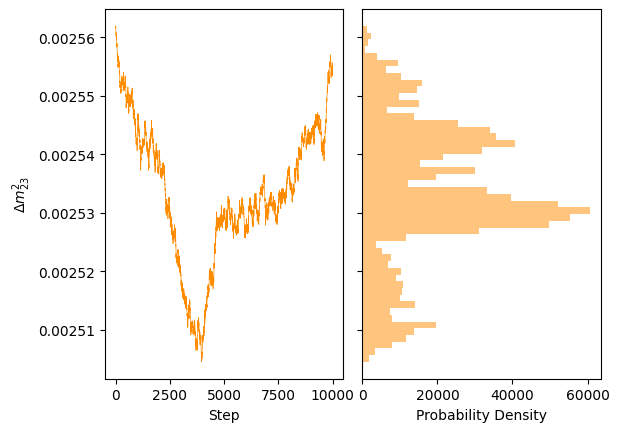

In [ ]:
#want item 27 for delm2_23 column's values
#delM_values =  []
#inv_stored_steps = [ml_model.invert_scaling(s.reshape(1,-1)) for s in stored_steps]

#for i in inv_stored_steps:
 #   delM_values.append(i[0][27])

#fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)
#x = np.arange(0,len(delM_values),1)
#trace_ax.plot(x, delM_values, linewidth=0.5, color='darkorange')
#trace_ax.set_ylabel(r'$\Delta m^2_{23}$')
#trace_ax.set_xlabel('Step')
##
#post_ax.hist(delM_values, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True)
#post_ax.set_xlabel('Probability Density')
# Merge the two axes
#plt.setp(post_ax.get_yticklabels(), visible=False)
#fig.subplots_adjust(wspace=.08)

In [ ]:
#Now we want to write something that will do both MCMC chains at the same time
#or store them separately at least so we have the two individual distributions of 
#the M23 for normal and inverted ordering. Then we can look at fitting the stuff
#and making a joint analysis i guess

Training Results!

Mean Absolute Error : 0.021195349297722012

Line of best fit : y=1.0174329408171217x + 0.006438948521252511

Saving QQ to train_qq_plot.pdf

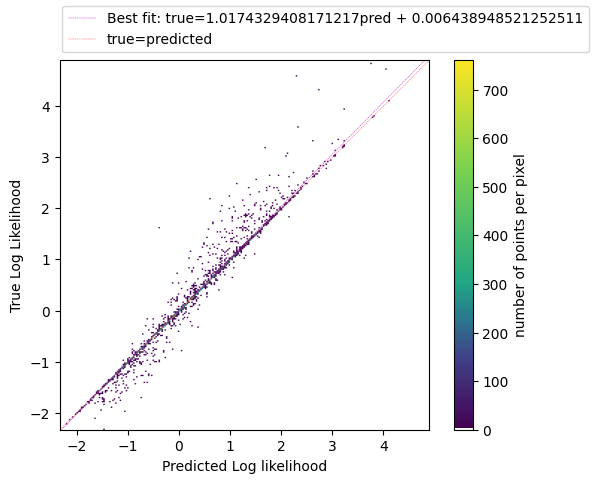

mean: 0.006328622027985107, std dev: 0.1096095396798569

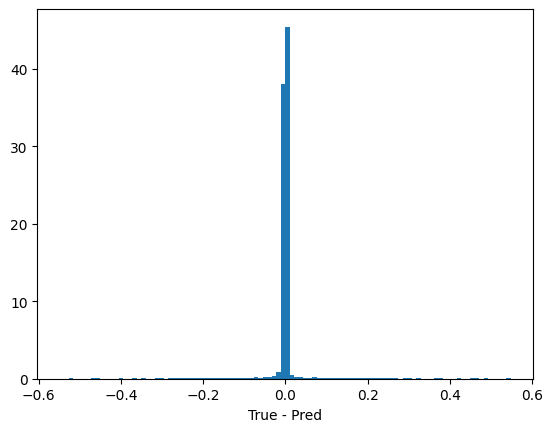

=====

Testing Results!

Mean Absolute Error : 0.02727394823570171

Line of best fit : y=1.0195972555000257x + 0.00830591533869058

Saving QQ to .pdf

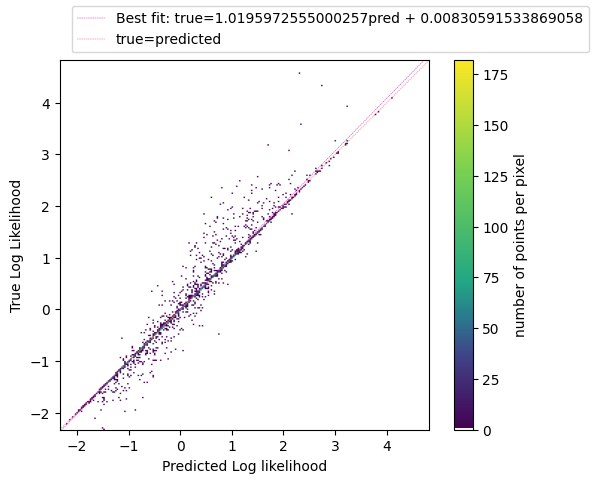

mean: 0.00798066952363957, std dev: 0.12352117697323554

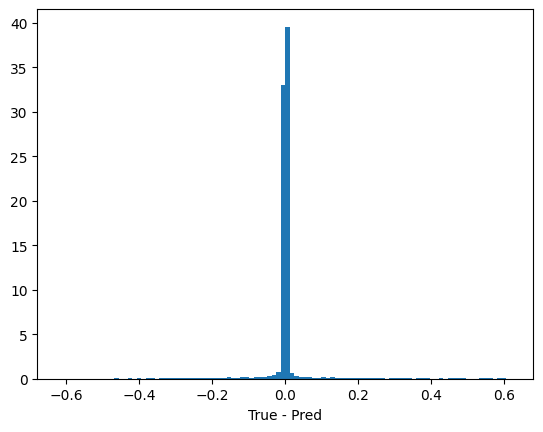

=====

In [ ]:
# Now we need to test
#ml_model.test_model()


In [ ]:
# Now we can save it
#ml_model.save_model(f"{model_output}.keras")


# We need to save the scaling information
#ml_model.save_scaler(str(model_output.parent.joinpath(Path("my_scaler.pkl"))))
#print("Model saved to: ", model_output)
#print("Scaler saved to: ", model_output.parent.joinpath(Path("my_scaler.pkl")))


Saving to ..\models\my_model.keras

Model saved to:  ..\models\my_model
Scaler saved to:  ..\models\my_scaler.pkl


In [ ]:
# def get_table_hacky():
#     chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
#     # Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
#     chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov", "xsec_20", "xsec_19"])
#     fitting_label = "LogL" #what target we want
#     # Now we add parameters we care about. Note this only need to be a substring of the full name
#     chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
#     # We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
#     chain_handler.add_additional_plots(fitting_label, True)

#     #specify the cut for the mass being tested
#     chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<1234", "step>10000"])
#     chain_handler.convert_ttree_to_array()
#     full_table = chain_handler.ttree_array

#     return full_table.copy()
